In [ ]:
#| default_exp user_guide

## Models zoo

The table below lists the models along with their descriptions and usage examples.

### Univariate forecasters

| **Models** | **Description** | **Usage Example** |
|----------|-----------|---------------|
| Naive Forecaster | A simple forecasting model that uses the last observed value or last seasonal value as the forecast. | <code> from peshbeen.models import naive <br> model = naive(target_col='target column name', season_period=None) <br> model.fit(df) <br> forecasts = model.forecast(H=10)|
| ETS (Exponential Smoothing state space models) | ETS forecaster that wraps the `statsmodels` implementation, allowing for easy integration and forecasting. | <code> from peshbeen.models import ets <br> model = ets(target_col='target column name', trend='add', seasonal='add', seasonal_periods=12, smoothing_level=0.1, smoothing_trend=0.1, smoothing_seasonal=0.1) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| ARIMA (AutoRegressive Integrated Moving Average) | ARIMA — a fast, familiar forecaster backed by Nixtla's `statsforecast` implementation, the fastest ARIMA in Python. | <code> from peshbeen.models import arima <br> model = arima(target_col='target column name', order=(1, 1, 1)) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| Machine Learning Regressors — any scikit-learn-compatible regressor, from LinearRegression, RandomForest and AdaBoost to XGBoost, LightGBM, and CatBoost. | A unified forecasting wrapper for any compatible regression model. | <code> from peshbeen.models import ml_forecaster <br> from sklearn.ensemble import RandomForestRegressor <br> model = ml_forecaster(target_col='target column name', estimator=RandomForestRegressor(n_estimators=100)) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| MS-ARR (Markov-Switching AutoRegressive Regression) | Models time series with hidden regime changes (e.g. recession vs. growth, low vs. high volatility) using autoregressive dynamics and optional exogenous variables. | <code>  from peshbeen.models import ms_arr <br> model = ms_arr(target_col='target column name', n_components=2, lags = 2, n_iter=100) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |

### Multivariate forecasters

| **Models** | **Description** | **Usage Example** |
|----------|-----------|---------------|
| VAR (Vector AutoRegression) | A pure-NumPy multivariate forecaster that models linear interdependencies across multiple time series, with per-series lag structure control. | <code> from peshbeen.models import var <br> model = var(target_cols=['target column 1', 'target column 2'], lags={'target column 1': 2, 'target column 2': [1, 2, 7]}) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| Machine Learning Regressors (multivariate) — any scikit-learn-compatible regressor, from LinearRegression and RandomForest to XGBoost, LightGBM, and CatBoost. | Forecasts multiple series simultaneously by leveraging interdependencies among them, using any scikit-learn-compatible regressor. | <code> from peshbeen.models import ml_mv_forecaster <br> from lightgbm import LGBMRegressor <br> model = ml_mv_forecaster(target_cols=['target column 1', 'target column 2'], estimator=LGBMRegressor(n_estimators=100, learning_rate=0.1), lags={'target column 1': 2, 'target column 2': [1, 2, 7]}) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| MS-VAR (Markov-Switching Vector AutoRegression) | A multivariate extension of MS-ARR that models multiple time series with hidden regime changes using vector autoregressive dynamics and optional exogenous variables. | <code> from peshbeen.models import ms_var <br> model = ms_var(target_cols=['target column 1', 'target column 2'], n_components=2, lags={'target column 1': 2, 'target column 2': [1, 2, 7]}, n_iter=100) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |

## Stationarity & Detrending Strategies

**What is stationarity?**

Stationarity is a fundamental concept in time series analysis that refers to the statistical properties of a time series being constant over time. A stationary time series has a constant mean, variance, and autocorrelation structure, which allows for more reliable modeling and forecasting. Non-stationary time series, on the other hand, exhibit trends, seasonality, or changing variance, making them more challenging to model accurately.

**Why is stationarity important?**

Many forecasting models, especially traditional statistical models like ARIMA and Machine Learning Regressors, assume that the underlying time series is stationary. If the data is non-stationary, these models may produce biased or inaccurate forecasts. By ensuring stationarity through techniques like differencing and detrending, we can improve the performance of these models and obtain more reliable forecasts.

The time series below is non-stationary, with an upward trend and weekly seasonality. We will use this time series to demonstrate how to apply different forecasting models, such as ETS, ARIMA, and Machine Learning models.

In [ ]:
#| hide
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = "#FBFAF4"
plt.rcParams['axes.facecolor'] = "#FBFAF4"

# dont show warnings
import warnings
warnings.filterwarnings("ignore")

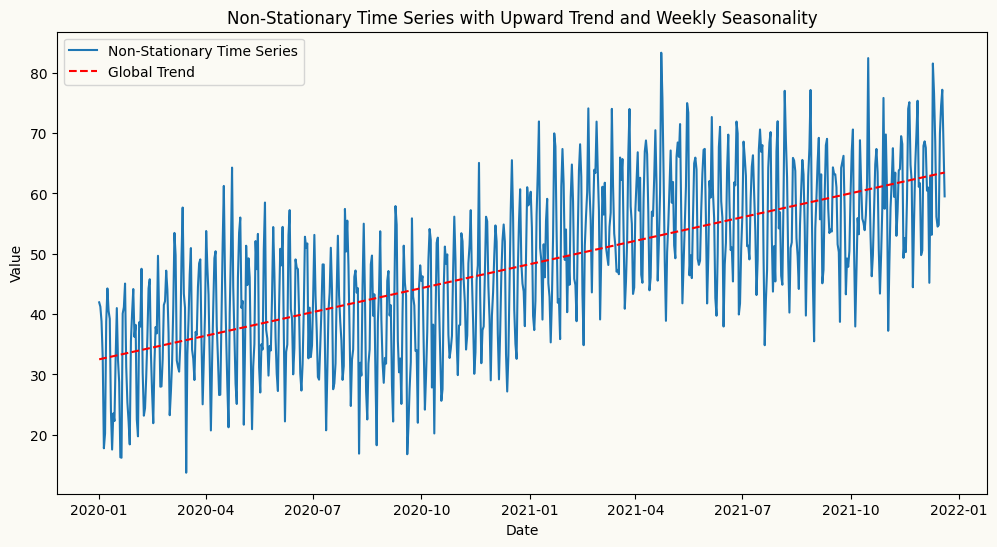

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
date_range = pd.date_range(start='2020-01-01', periods=720, freq='D')
# create a non-stationary time series with an upward trend weekly seasonality, yearly seasonality and some noise
np.random.seed(42)
data = 30 + 0.05 * np.arange(720) + 12 * np.sin(2 * np.pi * date_range.dayofyear / 7) + 5 * np.sin(2 * np.pi * date_range.dayofyear / 365) + np.random.normal(0, 5, 720)

time_series = pd.DataFrame(data, index=date_range, columns=['Value'])

# plot trend line using linear regression
from sklearn.linear_model import LinearRegression
X = np.arange(len(time_series)).reshape(-1, 1)
y = time_series['Value'].values
model = LinearRegression()
model.fit(X, y)
trend_line = model.predict(X)


plt.figure(figsize=(12, 6))
plt.plot(time_series.index, time_series['Value'], label='Non-Stationary Time Series')
plt.plot(time_series.index, trend_line, label='Global Trend', color='red', linestyle='--')
plt.title('Non-Stationary Time Series with Upward Trend and Weekly Seasonality')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()


Here, we forecast the same series using multiple models — starting with ETS, which handles non-stationary data natively, then ARIMA and ML regressors, where peshbeen's built-in detrending and transformation pipeline takes care of stationarity automatically.

**ETS Example**

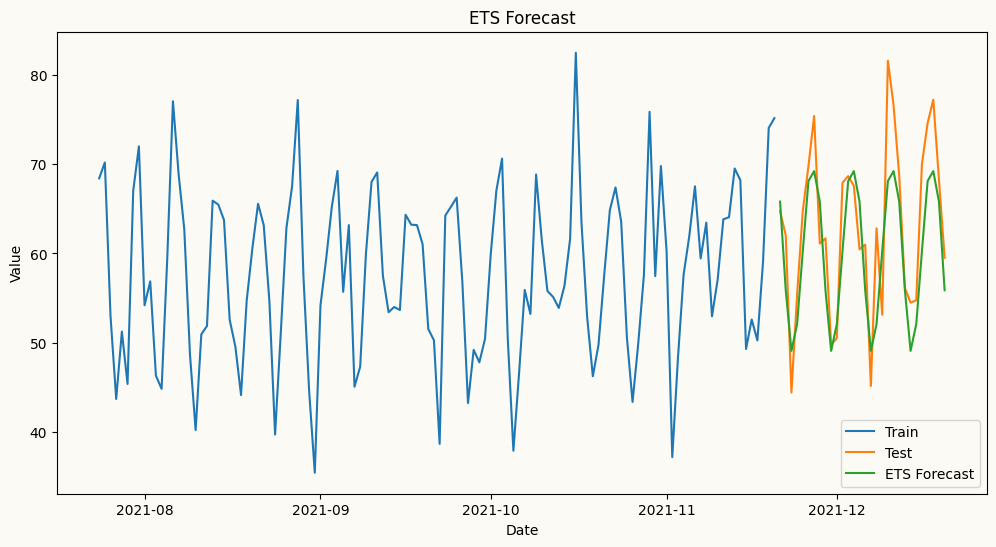

In [ ]:

from lightgbm import LGBMRegressor
train = time_series.iloc[:-30]
test = time_series.iloc[-30:]
from peshbeen.models import ets, arima, ml_forecaster
ets_model = ets(target_col='Value', seasonal = 'additive', seasonal_periods=7)
ets_model.fit(train)
ets_forecast = ets_model.forecast(H=30)
# plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['Value'][-120:], label='Train')
plt.plot(test.index, test['Value'], label='Test')
plt.plot(test.index, ets_forecast, label='ETS Forecast')
plt.title('ETS Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

**ARIMA Example**

Arima automatically applies differencing to make the series stationary by specifying the order of differencing (d) in the model parameters. In this example, we set d=1 to apply first-order differencing, which helps to remove the trend and make the series stationary for ARIMA modeling. To guide lag selection, we can also visualize the ACF and PACF plots of the original series to identify the ideal number of autoregressive (p) and moving average (q) terms for the ARIMA model. The ACF plot helps to identify the number of MA terms, while the PACF plot helps to identify the number of AR terms. As shown in the plots below, the ACF plot exhibits a slow decay, indicating non-stationarity, while the PACF plot shows significant spikes at lags 1 and 2, suggesting that an AR(2) model may be appropriate for the ARIMA model.

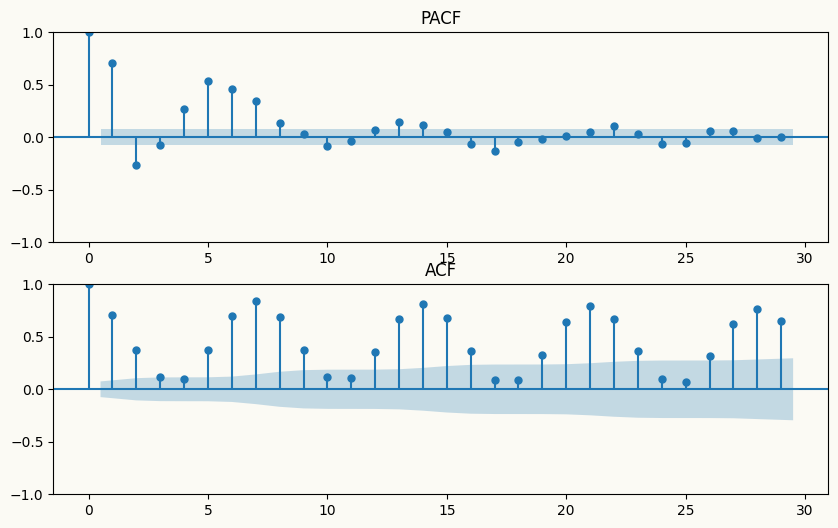

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

ward_cols_ =  ['blake', 'mulberry', 'juniper', 'magnolia', 'clare', 'anderson', 'other']
anon_wnames = ["Ward A", "Ward B", "Ward C", "Ward D", "Ward E", "Ward F", "Ward G"]

plot_pacf(train["Value"], ax=axes[0], title="PACF")
plot_acf(train["Value"], ax=axes[1], title="ACF")
plt.show()

Let's see how the forecasts look when doesn't apply differencing for ARIMA and machine learning forecasters using LightGBMRegressor as regressor.

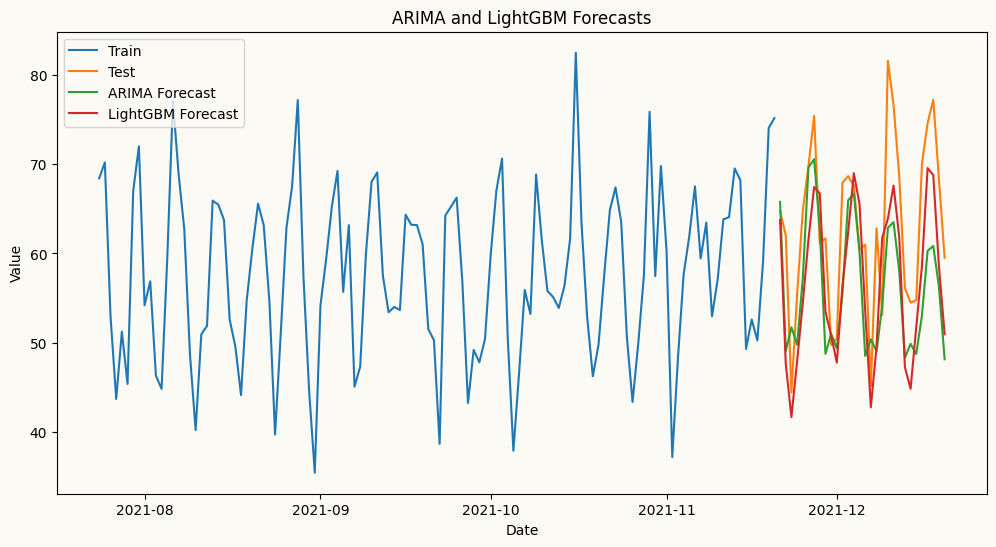

In [ ]:
# arima forecast
arima_model = arima(target_col='Value', order=(2,0,0), seasonal_order=(1,0,0), seasonal_length=7)
arima_model.fit(train)
arima_forecast = arima_model.forecast(H=30)

# ml forecast using lightgbm
lgb_model = ml_forecaster(target_col='Value',model=LGBMRegressor(verbose=-1, n_estimators=100, learning_rate=0.1), lags=7, trend='ets')
lgb_model.fit(train)
lgb_forecast = lgb_model.forecast(H=30)

# plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['Value'][-120:], label='Train')
plt.plot(test.index, test['Value'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.plot(test.index, lgb_forecast, label='LightGBM Forecast')
plt.title('ARIMA and LightGBM Forecasts')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

As shown in the plot above, the forecasts from the ARIMA model without differencing are underforecasting the upward trend in the data, resulting in forecasts that are significantly lower than the actual values. This highlights the importance of applying differencing to achieve stationarity when using ARIMA models, as it allows the model to capture the underlying patterns and trends in the data more effectively, leading to more accurate forecasts. Now, let's see how the forecasts look when we apply differencing for ARIMA.

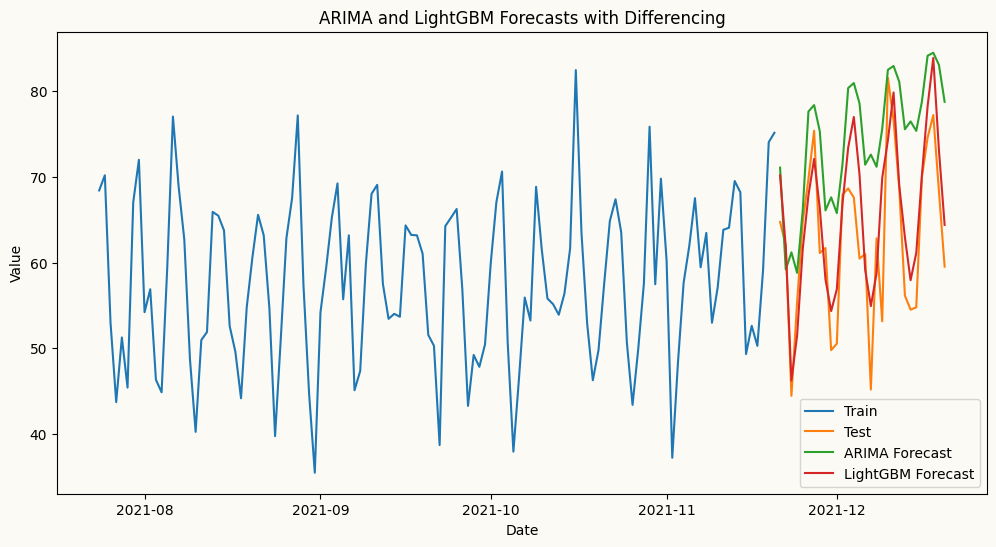

In [ ]:
# arima forecast
arima_model = arima(target_col='Value', order=(2,1,0), seasonal_order=(1,0,0), seasonal_length=7)
arima_model.fit(train)
arima_forecast = arima_model.forecast(H=30)

# ml forecast using lightgbm
lgb_model = ml_forecaster(target_col='Value',model=LGBMRegressor(verbose=-1, n_estimators=100, learning_rate=0.1), lags=7, difference=1)
lgb_model.fit(train)
lgb_forecast = lgb_model.forecast(H=30)
# plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['Value'][-120:], label='Train')
plt.plot(test.index, test['Value'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.plot(test.index, lgb_forecast, label='LightGBM Forecast')
plt.title('ARIMA and LightGBM Forecasts with Differencing')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

When differencing is applied to strongly trending data, ARIMA forecasts can overshoot significantly. This is because differencing removes the trend incrementally, but in the presence of a strong deterministic trend, it can inflate the model's variance and cause it to fit noise rather than signal — leading to poor out-of-sample performance.

This highlights an important practical consideration: differencing is not always the right tool for non-stationarity. When the trend is strong and smooth, more effective alternatives include detrending via linear regression, or piecewise linear regression when structural breaks are present. When the data also exhibits local seasonality or a time-varying trend, a better approach is to first fit an ETS model to capture those components, then apply ARIMA to the residuals.

Rather than differencing, we can detrend the series by fitting a linear regression to the original time series, extracting the underlying trend, and passing the residuals to ARIMA or ML regressors. This is a valid and often more stable approach to achieving stationarity when the trend is deterministic and approximately linear — the residuals are stationary by construction, and the forecasting model focuses purely on the remaining dynamics. peshbeen's detrending pipeline handles this automatically.

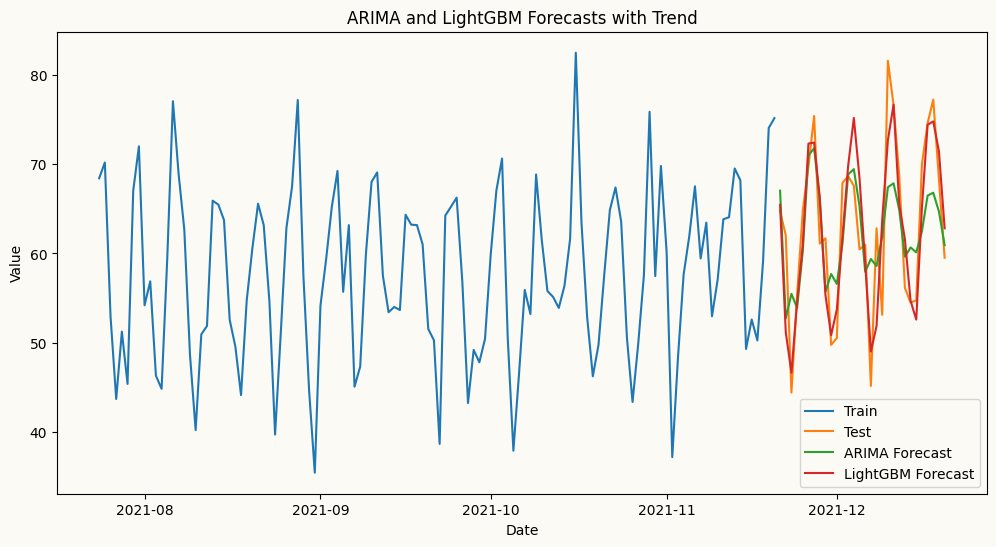

In [ ]:
# arima forecast
arima_model = arima(target_col='Value', order=(2,0,0), seasonal_order=(1,0,0), seasonal_length=7, trend='linear')
arima_model.fit(train)
arima_forecast = arima_model.forecast(H=30)

# ml forecast using lightgbm
lgb_model = ml_forecaster(target_col='Value',model=LGBMRegressor(verbose=-1, n_estimators=100, learning_rate=0.1), lags=7, trend='linear')
lgb_model.fit(train)
lgb_forecast = lgb_model.forecast(H=30)

# plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['Value'][-120:], label='Train')
plt.plot(test.index, test['Value'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.plot(test.index, lgb_forecast, label='LightGBM Forecast')
plt.title('ARIMA and LightGBM Forecasts with Trend')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()